# AI 정규 스터디 2주차 - 데이터 분할과 스케일링

## 수업시간 실습


In [2]:
fish_length = [
    25.4,
    26.3,
    26.5,
    29.0,
    29.0,
    29.7,
    29.7,
    30.0,
    30.0,
    30.7,
    31.0,
    31.0,
    31.5,
    32.0,
    32.0,
    32.0,
    33.0,
    33.0,
    33.5,
    33.5,
    34.0,
    34.0,
    34.5,
    35.0,
    35.0,
    35.0,
    35.0,
    36.0,
    36.0,
    37.0,
    38.5,
    38.5,
    39.5,
    41.0,
    41.0,
    9.8,
    10.5,
    10.6,
    11.0,
    11.2,
    11.3,
    11.8,
    11.8,
    12.0,
    12.2,
    12.4,
    13.0,
    14.3,
    15.0,
]
fish_weight = [
    242.0,
    290.0,
    340.0,
    363.0,
    430.0,
    450.0,
    500.0,
    390.0,
    450.0,
    500.0,
    475.0,
    500.0,
    500.0,
    340.0,
    600.0,
    600.0,
    700.0,
    700.0,
    610.0,
    650.0,
    575.0,
    685.0,
    620.0,
    680.0,
    700.0,
    725.0,
    720.0,
    714.0,
    850.0,
    1000.0,
    920.0,
    955.0,
    925.0,
    975.0,
    950.0,
    6.7,
    7.5,
    7.0,
    9.7,
    9.8,
    8.7,
    10.0,
    9.9,
    9.8,
    12.2,
    13.4,
    12.2,
    19.7,
    19.9,
]

In [3]:
fish_data = [[l, w] for l, w in zip(fish_length, fish_weight)]
fish_target = [1] * 35 + [0] * 14

print(fish_data)
print(fish_target)

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0], [29.7, 450.0], [29.7, 500.0], [30.0, 390.0], [30.0, 450.0], [30.7, 500.0], [31.0, 475.0], [31.0, 500.0], [31.5, 500.0], [32.0, 340.0], [32.0, 600.0], [32.0, 600.0], [33.0, 700.0], [33.0, 700.0], [33.5, 610.0], [33.5, 650.0], [34.0, 575.0], [34.0, 685.0], [34.5, 620.0], [35.0, 680.0], [35.0, 700.0], [35.0, 725.0], [35.0, 720.0], [36.0, 714.0], [36.0, 850.0], [37.0, 1000.0], [38.5, 920.0], [38.5, 955.0], [39.5, 925.0], [41.0, 975.0], [41.0, 950.0], [9.8, 6.7], [10.5, 7.5], [10.6, 7.0], [11.0, 9.7], [11.2, 9.8], [11.3, 8.7], [11.8, 10.0], [11.8, 9.9], [12.0, 9.8], [12.2, 12.2], [12.4, 13.4], [13.0, 12.2], [14.3, 19.7], [15.0, 19.9]]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### 순서대로 분리 (샘플링 편향 발생)


In [4]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

train_input = fish_data[:35]
train_target = fish_target[:35]
test_input = fish_data[35:]
test_target = fish_target[35:]

kn.fit(train_input, train_target)
kn.score(test_input, test_target)

0.0

### 셔플을 이용한 분리


In [5]:
import numpy as np

input_arr = np.array(fish_data)
target_arr = np.array(fish_target)

np.random.seed(42)
index = np.arange(49)
np.random.shuffle(index)
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [6]:
train_input = input_arr[index[:35]]
train_target = target_arr[index[:35]]
test_input = input_arr[index[35:]]
test_target = target_arr[index[35:]]

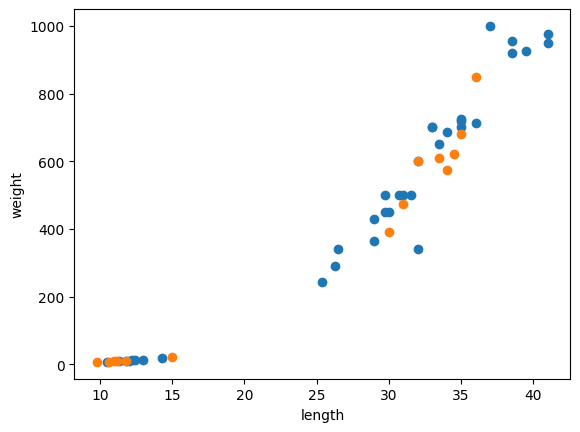

In [7]:
import matplotlib.pyplot as plt

plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(test_input[:, 0], test_input[:, 1])
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [8]:
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

### train_test_split 사용


In [9]:
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

print(fish_data[:5])
print(fish_target)

[[ 25.4 242. ]
 [ 26.3 290. ]
 [ 26.5 340. ]
 [ 29.  363. ]
 [ 29.  430. ]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [10]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42
)

print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)
print(test_target)

(36, 2) (13, 2)
(36,) (13,)
[1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, stratify=fish_target, random_state=42
)

print(test_target)

[0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1.]


In [12]:
kn = KNeighborsClassifier()
kn.fit(train_input, train_target)
kn.score(test_input, test_target)

1.0

### 스케일 문제 확인


In [13]:
print(kn.predict([[25, 150]]))

[0.]


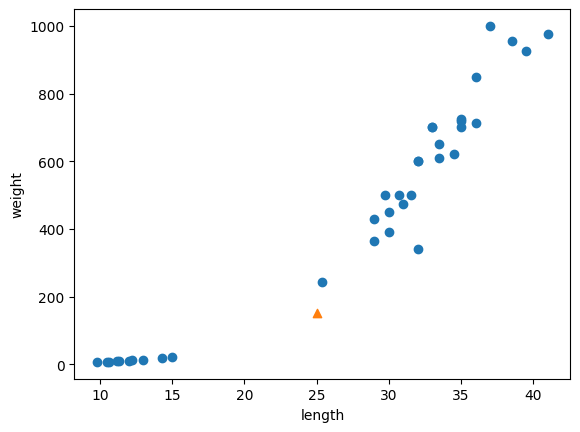

In [14]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

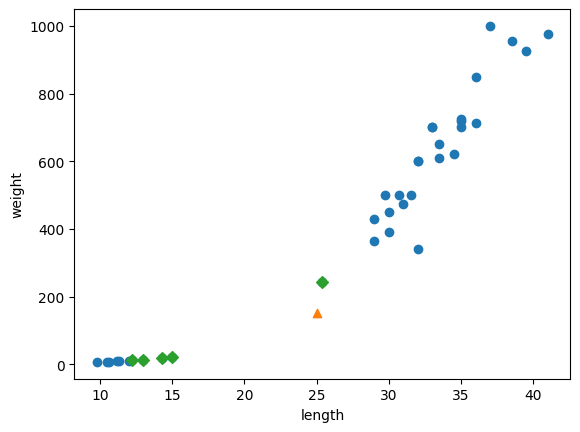

In [15]:
distances, indexes = kn.kneighbors([[25, 150]])

plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker="D")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [16]:
print(train_input[indexes])
print(train_target[indexes])
print(distances)

[[[ 25.4 242. ]
  [ 15.   19.9]
  [ 14.3  19.7]
  [ 13.   12.2]
  [ 12.2  12.2]]]
[[1. 0. 0. 0. 0.]]
[[ 92.00086956 130.48375378 130.73859415 138.32150953 138.39320793]]


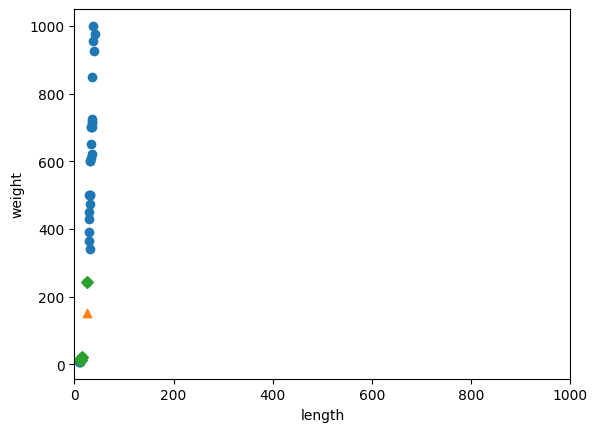

In [17]:
plt.scatter(train_input[:, 0], train_input[:, 1])
plt.scatter(25, 150, marker="^")
plt.scatter(train_input[indexes, 0], train_input[indexes, 1], marker="D")
plt.xlim((0, 1000))
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

### 표준점수 스케일링


In [18]:
mean = np.mean(train_input, axis=0)
std = np.std(train_input, axis=0)
print(mean, std)

[ 27.29722222 454.09722222] [  9.98244253 323.29893931]


In [19]:
train_scaled = (train_input - mean) / std

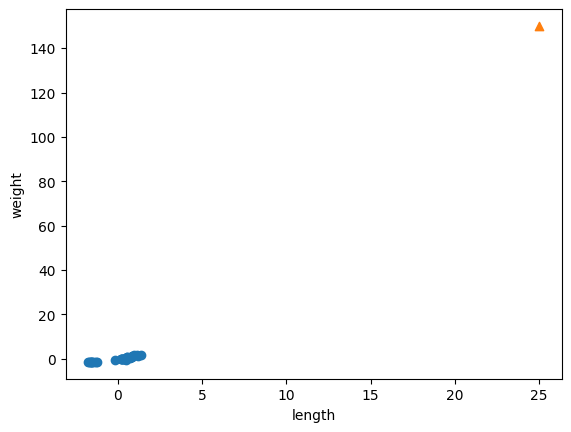

In [20]:
plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(25, 150, marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

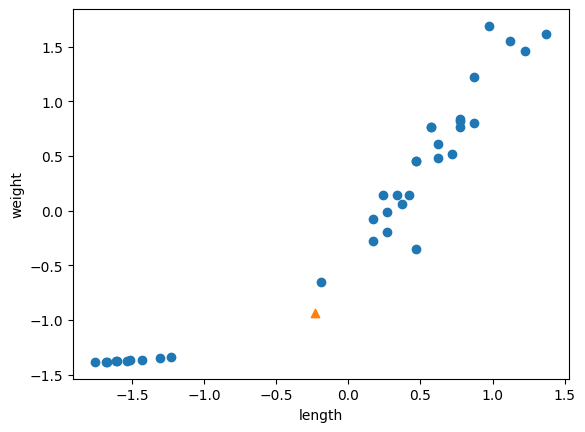

In [21]:
new = ([25, 150] - mean) / std

plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker="^")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

In [22]:
kn.fit(train_scaled, train_target)

test_scaled = (test_input - mean) / std
kn.score(test_scaled, test_target)

1.0

In [23]:
print(kn.predict([new]))

[1.]


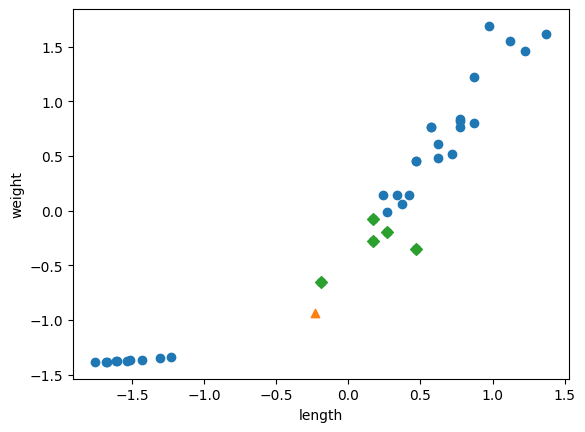

In [24]:
distances, indexes = kn.kneighbors([new])

plt.scatter(train_scaled[:, 0], train_scaled[:, 1])
plt.scatter(new[0], new[1], marker="^")
plt.scatter(train_scaled[indexes, 0], train_scaled[indexes, 1], marker="D")
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

---

## 과제


### 과제 1: 다양한 비율로 데이터 분리 및 KNN 정확도 비교


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.concatenate((np.ones(35), np.zeros(14)))

# Q1. test_size 파라미터를 사용해 7:3으로 데이터를 분리해봐요
train_input_7, test_input_7, train_target_7, test_target_7 = train_test_split(
    fish_data, fish_target, test_size=0.3, random_state=42, stratify=fish_target
)

# Q2. 5:5로 분리해봐요
train_input_5, test_input_5, train_target_5, test_target_5 = train_test_split(
    fish_data, fish_target, test_size=0.5, random_state=42, stratify=fish_target
)

# Q3. 9:1로 분리해봐요
train_input_9, test_input_9, train_target_9, test_target_9 = train_test_split(
    fish_data, fish_target, test_size=0.1, random_state=42, stratify=fish_target
)

# Q4. 위의 1, 2, 3번의 분리 결과로 KNN 알고리즘의 정확도를 테스트 해봐요
kn = KNeighborsClassifier()
# 7:3
kn.fit(train_input_7, train_target_7)
print(f"[7:3 비율] 정확도: {kn.score(test_input_7, test_target_7)}")
# 5:5
kn.fit(train_input_5, train_target_5)
print(f"[5:5 비율] 정확도: {kn.score(test_input_5, test_target_5)}")
# 9:1
kn.fit(train_input_9, train_target_9)
print(f"[9:1 비율] 정확도: {kn.score(test_input_9, test_target_9)}")

# 7:3 분리 결과 확인 (hint: len() 사용)
print(
    f"[7:3 비율] 훈련 세트: {len(train_input_7)}개, 테스트 세트: {len(test_input_7)}개"
)

# 5:5 분리 결과 확인 (hint: len() 사용)
print(
    f"[5:5 비율] 훈련 세트: {len(train_input_5)}개, 테스트 세트: {len(test_input_5)}개"
)

# 9:1 분리 결과 확인 (hint: len() 사용)
print(
    f"[9:1 비율] 훈련 세트: {len(train_input_9)}개, 테스트 세트: {len(test_input_9)}개"
)

[7:3 비율] 정확도: 1.0
[5:5 비율] 정확도: 1.0
[9:1 비율] 정확도: 0.8
[7:3 비율] 훈련 세트: 34개, 테스트 세트: 15개
[5:5 비율] 훈련 세트: 24개, 테스트 세트: 25개
[9:1 비율] 훈련 세트: 44개, 테스트 세트: 5개


### 과제 2: Numpy 없이 순수 파이썬으로 표준점수 스케일링하기


In [41]:
lengths = [fish[0] for fish in train_input]
weights = [fish[1] for fish in train_input]
n = len(train_input)

# Q1. sum() 함수를 이용해 길이와 무게의 평균을 구하세요.
mean_length = sum(lengths) / n
mean_weight = sum(weights) / n

# Q2. for문과 ** 연산자를 이용해 길이와 무게의 분산을 구하세요.
# 힌트: 분산 = (각 데이터 - 평균)의 제곱의 합 / 데이터 개수
var_length = sum((length - mean_length) ** 2 for length in lengths) / n
var_weight = sum((weight - mean_weight) ** 2 for weight in weights) / n

# Q3. 분산에 제곱근을 씌워 표준편차를 구하세요. ( ** 0.5 이용 )
std_length = var_length**0.5
std_weight = var_weight**0.5

# Q4. 구해진 평균과 표준편차를 이용해 train_input의 모든 데이터를 스케일링하여 새로운 리스트에 담으세요.
train_scaled_manual = []
for fish in train_input:
    scaled_length = (fish[0] - mean_length) / std_length
    scaled_weight = (fish[1] - mean_weight) / std_weight
    train_scaled_manual.append([scaled_length, scaled_weight])

# 확인용 평균과 표준편차 출력
print(f"수동 계산 평균: {mean_length:.2f}, {mean_weight:.2f}")
print(f"수동 계산 표준편차: {std_length:.2f}, {std_weight:.2f}")
print(f"스케일링된 첫 데이터: {train_scaled_manual[0]}")

수동 계산 평균: 27.30, 454.10
수동 계산 표준편차: 9.98, 323.30
스케일링된 첫 데이터: [np.float64(0.2407003866560286), np.float64(0.1419824570898689)]


### 과제 3: 스케일링된 데이터 시각화


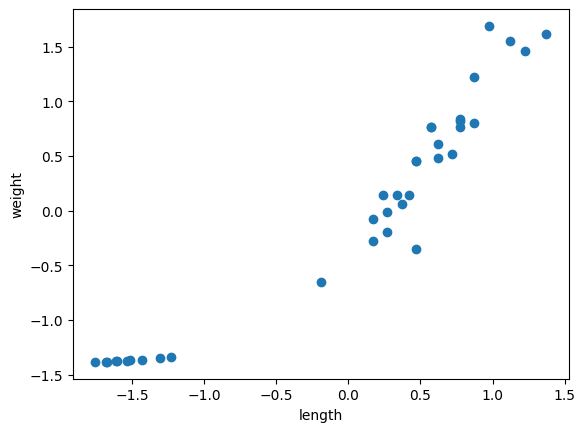

In [42]:
import matplotlib.pyplot as plt

# 1. 스케일링된 2차원 리스트에서 길이(X축)와 무게(Y축) 데이터 분리하기
scaled_lengths = [fish[0] for fish in train_scaled_manual]
scaled_weights = [fish[1] for fish in train_scaled_manual]

# 2. 산점도 그리기
plt.scatter(scaled_lengths, scaled_weights)
plt.xlabel("length")
plt.ylabel("weight")
plt.show()